Network Characterization and Visualization

In [ ]:
# import libraries
import sys
import os
import logging
import powerlaw
import igraph as ig
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
import seaborn as sns
import pandas as pd
import numpy as np

# Add the parent directory to sys.path to enable imports from analysis subfolder
sys.path.append(os.path.abspath(".."))

# import functions
from load_graph import load_graph
from fit_degrees_to_power_law import fit_degrees_to_power_law
from fit_degrees_to_power_law import fit_degrees_to_power_law_files
from median_degree_by_depth import median_degree_by_depth
from top_n_no_share_hostnames import no_share_hostnames

In [ ]:
# Fit Degrees to Power Law
nodes = r"../../data_sample_snapshots/snapshot-2026-07-19-201026-nodes.parquet"
edges = r"../../data_sample_snapshots/snapshot-2026-07-19-201026-edges.parquet"

fits = fit_degrees_to_power_law_files(nodes, edges)

print("Alpha:", fits["in"]["alpha"])
print("Xmin:", fits["in"]["xmin"])
print("R:", fits["in"]["R"], "p:", fits["in"]["p"])

c:\Users\qiaox\AppData\Local\Programs\Python\Python312\Lib\site-packages\powerlaw\fitting.py:264: UserWarning: Values less than or equal to 0 in data. Throwing out 0 or negative values.
  warnings.warn("Values less than or equal to 0 in data. Throwing out 0 or negative values.")


Calculating best minimal value for power law fit


Fitting xmin: 100%|██████████| 5962/5962 [02:53<00:00, 34.28it/s]


Alpha: 2.4370302156355264
Xmin: 2819.0
R: -0.6644051091480033 p: 0.5064310637273535


In [21]:
# Load graph once for downstream EDA
G = load_graph(nodes, edges)

In [22]:
# Inspect graph elements
print(G.vs.attributes())
print(type(G))
print(G.vcount(), G.ecount())

['name', 'label', 'hostname', 'preferred_username', 'published', 'type', 'followers_count', 'following_count', 'depth', 'followers_pages_complete', 'following_pages_complete', 'followers_members_shared', 'following_members_shared']
<class 'igraph.Graph'>
6226317 134475049


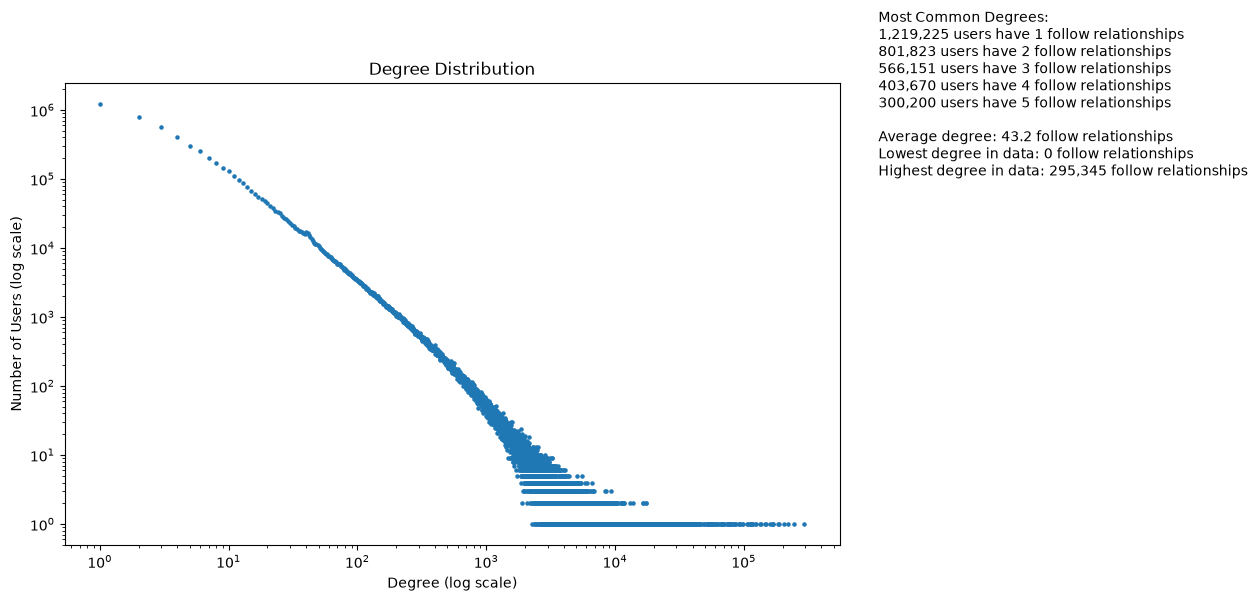

In [23]:
# Degree Distribution
# Example Reference: https://networkx.org/documentation/networkx-2.5/auto_examples/drawing/plot_degree_histogram.html :)

from collections import Counter

degrees = G.degree()
degree_count = Counter(degrees)

degree = list(degree_count.keys())
count = list(degree_count.values())

plt.figure(figsize=(10, 6))
plt.scatter(degree, count, s=5)

plt.xscale("log")
plt.yscale("log")

plt.title("Degree Distribution")
plt.xlabel("Degree (log scale)")
plt.ylabel("Number of Users (log scale)")

# Side text with top degrees
text = "Most Common Degrees:\n"

for degree, users in degree_count.most_common(5): # Currently at top 5 most common
    text += f"{users:,} users have {degree} follow relationships\n"

# Average Degree plus highests/lowest degrees
# "Median Degree by Depth Distribution" may be a better future metric
average_degree = sum(degrees) / len(degrees)
lowest_degree = min(degrees)
highest_degree = max(degrees)

text += f"\nAverage degree: {average_degree:.1f} follow relationships"
text += f"\nLowest degree in data: {lowest_degree} follow relationships"
text += f"\nHighest degree in data: {highest_degree:,} follow relationships"

plt.text(
    1.05, 0.8,
    text,
    transform=plt.gca().transAxes
)

plt.show()

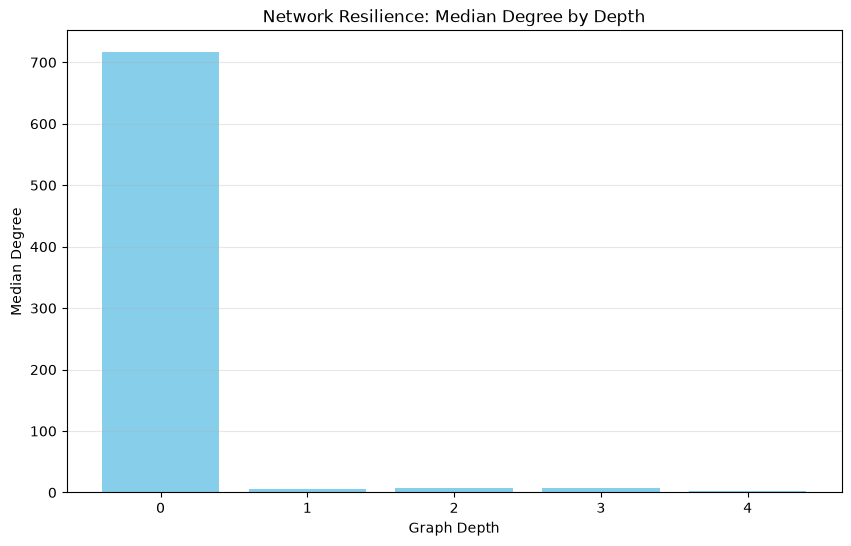

In [24]:
# Median Degree by Depth Distribution
dbd = median_degree_by_depth(G)
depths = sorted(dbd.keys())
medians = [dbd[d] for d in depths]

plt.figure(figsize=(10, 6))
plt.bar(depths, medians, color='skyblue')
plt.xlabel("Graph Depth")
plt.ylabel("Median Degree")
plt.title("Network Resilience: Median Degree by Depth")
plt.grid(axis='y', alpha=0.3)
plt.show()

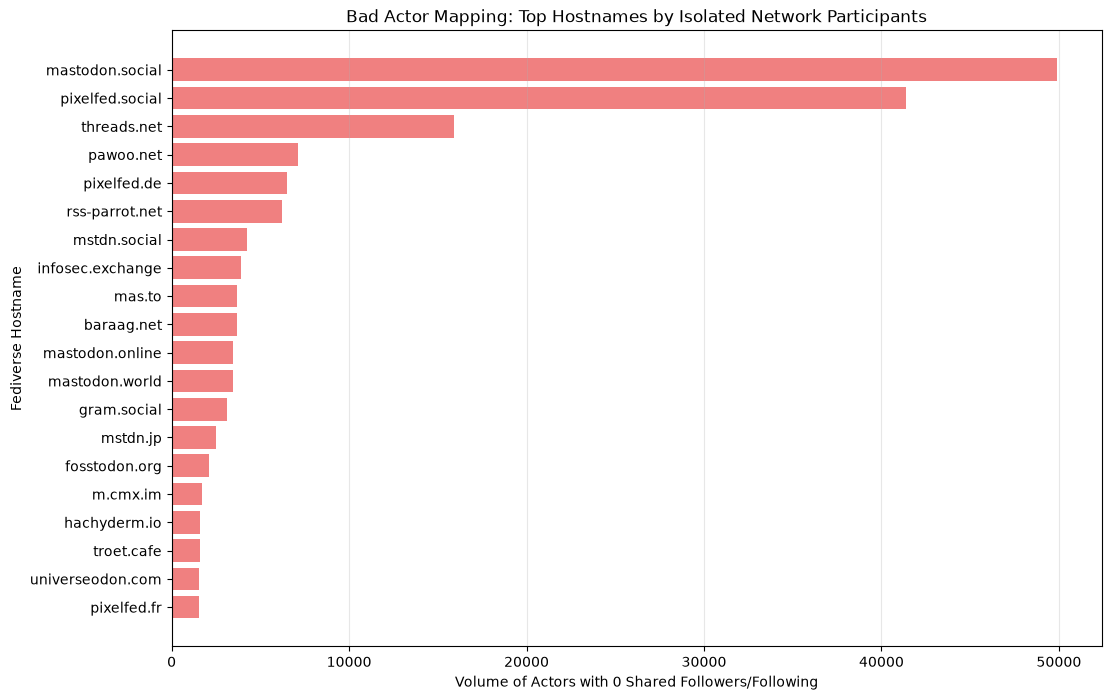

In [25]:
# Isolated Hostnames Mapping
isolated_hosts = no_share_hostnames(G)

# Extract top 20 most isolated instances
top_isolated = sorted(isolated_hosts.items(), key=lambda x: x[1], reverse=True)[:20]
hosts, counts = zip(*top_isolated)

plt.figure(figsize=(12, 8))
plt.barh(hosts, counts, color='lightcoral')
plt.xlabel("Volume of Actors with 0 Shared Followers/Following")
plt.ylabel("Fediverse Hostname")
plt.title("Bad Actor Mapping: Top Hostnames by Isolated Network Participants")
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)
plt.show()

In [26]:
# Top Isolated Hostname Nodes
isolated_hosts = no_share_hostnames(G)
top_isolated_domains = [host for host, count in sorted(isolated_hosts.items(), key=lambda x: x[1], reverse=True)[:5]]

# Extract vertex indices matching these hostnames
target_vids = [v.index for v in G.vs if v["hostname"] in top_isolated_domains]

# Function: analyze_ego_networks
# Purpose: Calculates 1-hop structural ego-network density and community modularity to identify localized isolation or clustering behaviors characteristic of coordinated bot networks or malicious actors.
# Inputs: 
#   - g: Graph instance representing the global Fediverse social network.
#   - target_vids: list of integer vertex IDs representing the target nodes
# Outputs: A pandas.DataFrame containing columns for node_id, ego_size, network density, and Louvain modularity score for each target.
def analyze_ego_networks(g, target_vids):
    metrics = []
    for vid in target_vids:
        # Extract 1-hop ego network
        neighbors = g.neighborhood(vertices=vid, order=1, mode="all")
        ego_subgraph = g.subgraph(neighbors)
        
        n_nodes = ego_subgraph.vcount()
        n_edges = ego_subgraph.ecount()
        
        # Ego density
        density = (2.0 * n_edges) / (n_nodes * (n_nodes - 1)) if n_nodes > 1 else 0.0
        
        # Local modularity via Louvain
        if n_nodes > 3 and n_edges > 0:
            communities = ego_subgraph.community_multilevel()
            modularity = communities.modularity
        else:
            modularity = 0.0
            
        metrics.append({
            "node_id": g.vs[vid]["name"],
            "ego_size": n_nodes,
            "density": density,
            "modularity": modularity
        })
    return pd.DataFrame(metrics)

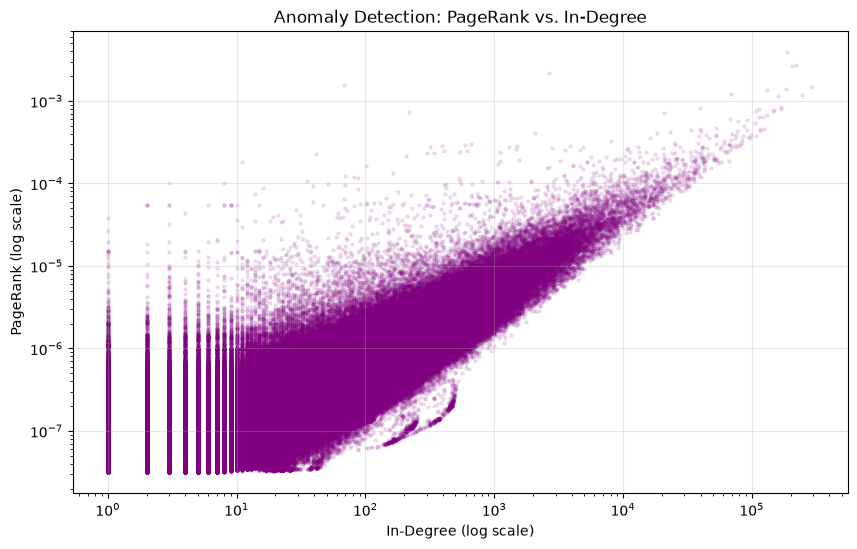

In [27]:
# PageRank vs. In-Degree Anomaly Plot
in_degrees = G.degree(mode="in")
pageranks = G.pagerank(directed=True)

plt.figure(figsize=(10, 6))
# Use low alpha and small marker size to handle 100k+ overplotting
plt.scatter(in_degrees, pageranks, alpha=0.1, s=5, c='purple')
plt.xscale('log')
plt.yscale('log')
plt.xlabel("In-Degree (log scale)")
plt.ylabel("PageRank (log scale)")
plt.title("Anomaly Detection: PageRank vs. In-Degree")
plt.grid(True, alpha=0.3)
plt.show()

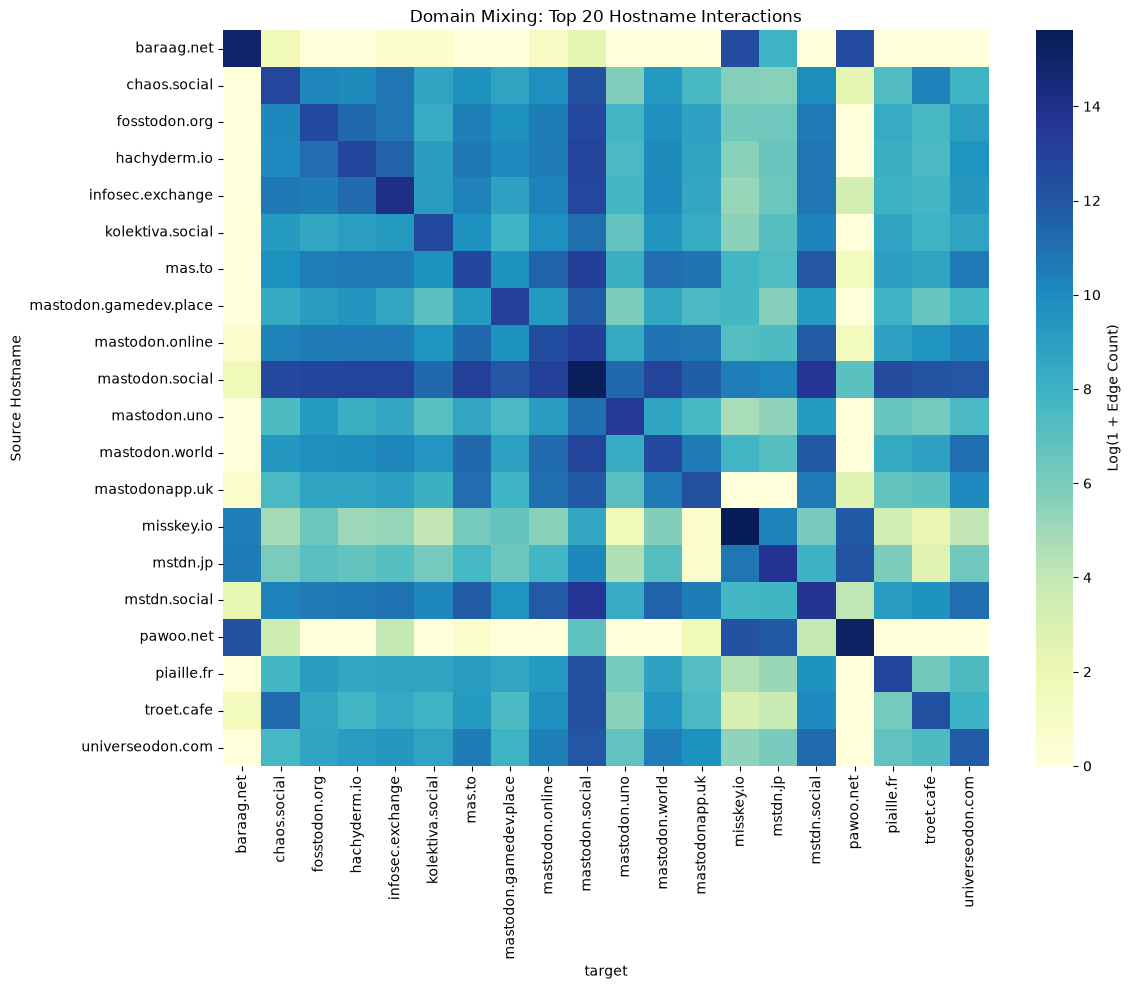

In [28]:
# Instance-Level Domain Mixing Heatmap
# Extract edge endpoints and map to hostnames
source_hosts = []
target_hosts = []

for e in G.es:
    s_host = G.vs[e.source]["hostname"]
    t_host = G.vs[e.target]["hostname"]
    if s_host and t_host:
        source_hosts.append(s_host)
        target_hosts.append(t_host)

df_edges = pd.DataFrame({'source': source_hosts, 'target': target_hosts})

# Filter to top 20 most active hostnames to construct a readable matrix
top_hosts = df_edges['source'].value_counts().head(20).index
df_filtered = df_edges[df_edges['source'].isin(top_hosts) & df_edges['target'].isin(top_hosts)]

# Generate matrix using log1p to normalize massive volume skews
matrix = pd.crosstab(df_filtered['source'], df_filtered['target'])
plt.figure(figsize=(12, 10))
sns.heatmap(np.log1p(matrix), cmap="YlGnBu", annot=False, cbar_kws={'label': 'Log(1 + Edge Count)'})
plt.title("Domain Mixing: Top 20 Hostname Interactions")
plt.ylabel("Source Hostname")
plt.tight_layout()
plt.show()


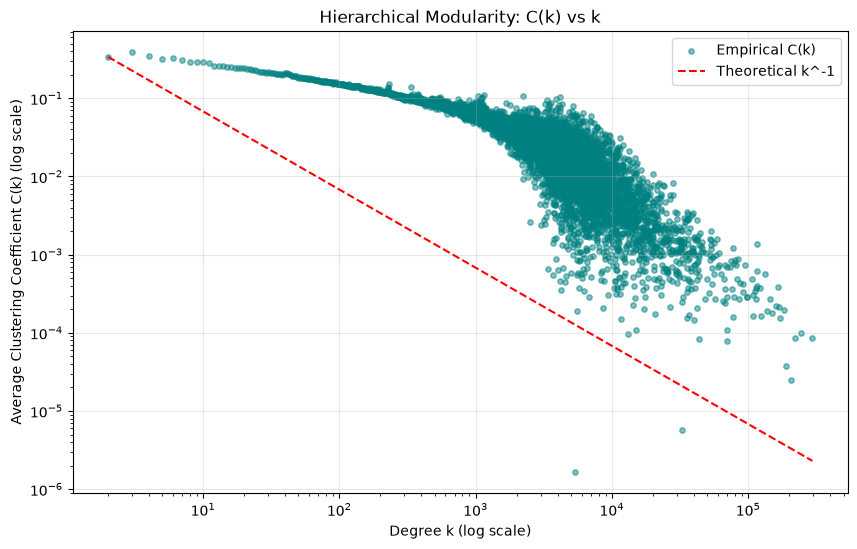

In [29]:
# Local Clustering Coefficient vs. Degree
degrees = np.array(G.degree(mode="all"))
# Calculate local clustering coefficient; mode="zero" returns 0 for undefined vertices
clustering = np.array(G.transitivity_local_undirected(mode="zero"))

# Filter isolated nodes (degree < 2)
valid_idx = degrees >= 2
deg_valid = degrees[valid_idx]
cc_valid = clustering[valid_idx]

# Average clustering coefficient by degree k
df_cc = pd.DataFrame({'degree': deg_valid, 'cc': cc_valid})
mean_cc_by_degree = df_cc.groupby('degree')['cc'].mean().reset_index()

k = mean_cc_by_degree['degree'].values
c_k = mean_cc_by_degree['cc'].values

plt.figure(figsize=(10, 6))
plt.scatter(k, c_k, alpha=0.5, s=15, c='teal', label='Empirical C(k)')

# Calculate theoretical k^-1 reference line based on starting point
k_ref = np.linspace(min(k), max(k), 100)
c_ref = c_k[0] * (k_ref / k[0])**-1 
plt.plot(k_ref, c_ref, color='red', linestyle='dashed', label='Theoretical k^-1')

plt.xscale('log')
plt.yscale('log')
plt.xlabel("Degree k (log scale)")
plt.ylabel("Average Clustering Coefficient C(k) (log scale)")
plt.title("Hierarchical Modularity: C(k) vs k")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

<Axes: title={'center': 'No edges matching overlap threshold.'}>

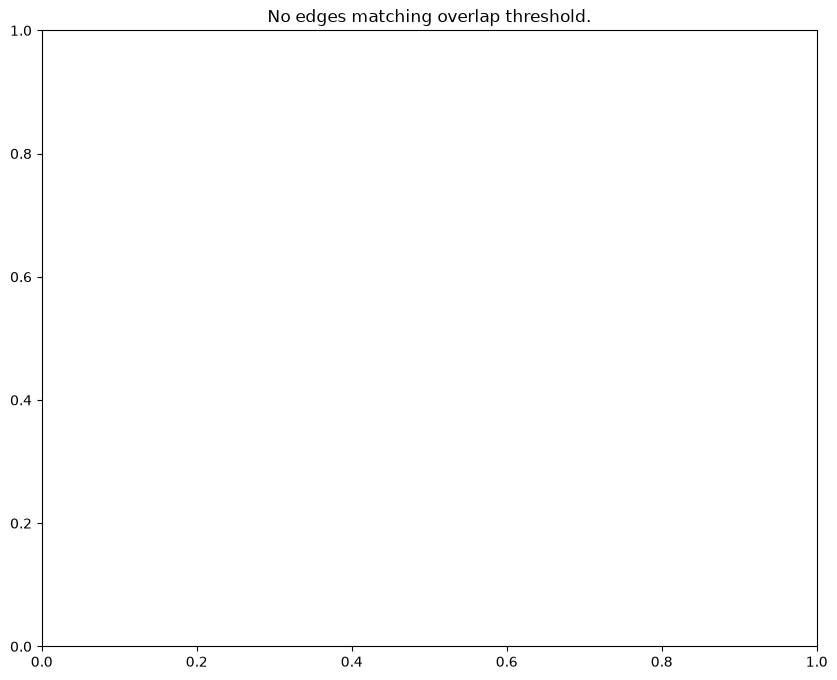

In [39]:
def plot_cib_overlap_graph(
    g: ig.Graph, 
    overlap_threshold: float = 0.8, 
    ax: plt.Axes = None, 
    figsize: tuple = (10, 8)
):
    """
    CIB overlap visualization using native igraph filtering and fast LineCollection vector rendering.
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)

    # Fast edge attribute extraction & vector threshold filtering
    f_shared = np.array(g.es["followers_members_shared"] if "followers_members_shared" in g.es.attributes() else [0] * g.ecount())
    fg_shared = np.array(g.es["following_members_shared"] if "following_members_shared" in g.es.attributes() else [0] * g.ecount())
    
    mask = (f_shared >= overlap_threshold) | (fg_shared >= overlap_threshold)
    edge_indices = np.where(mask)[0]
    
    if len(edge_indices) == 0:
        ax.set_title("No edges matching overlap threshold.")
        return ax

    # Extract edge-induced subgraph
    subg = g.subgraph_edges(edge_indices, delete_vertices=True)
    
    # Fast force-directed layout
    layout = subg.layout_fruchterman_reingold()
    coords = np.array(layout.coords)
    
    # Vectorized edge coordinates for LineCollection
    edges = subg.get_edgelist()
    edge_lines = [[coords[u], coords[v]] for u, v in edges]
    lc = LineCollection(edge_lines, colors="#888888", alpha=0.25, linewidths=0.8)
    ax.add_collection(lc)

    # Color mapping based on node label
    labels = np.array(subg.vs["label"] if "label" in subg.vs.attributes() else ["benign"] * subg.vcount())
    colors = np.where(labels == "bad_actor", "#d9534f", "#428bca")
    
    ax.scatter(coords[:, 0], coords[:, 1], c=colors, s=30, zorder=3, edgecolors="none")
    ax.set_title(f"CIB Overlap Graph (Shared Threshold ≥ {overlap_threshold})")
    ax.axis("off")
    return ax
plot_cib_overlap_graph(G)

<Axes: title={'center': 'Core Infiltration Radial Network (Depths 0–5)'}>

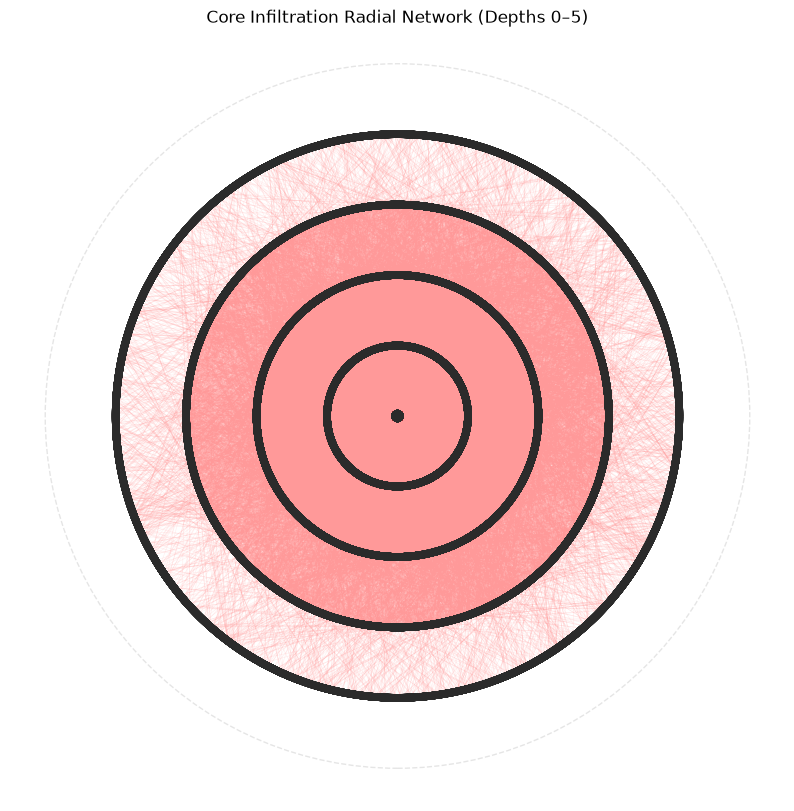

In [38]:
def plot_core_infiltration_network(
    g: ig.Graph, 
    max_depth: int = 3, 
    max_nodes: int = 2000, 
    ax: plt.Axes = None, 
    figsize: tuple = (10, 10)
):
    """
    Refactored radial core infiltration graph placing nodes concentrically 
    by their graph depth attribute.
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)

    # Fast node extraction by depth
    depths = np.array(g.vs["depth"] if "depth" in g.vs.attributes() else [0] * g.vcount())
    valid_mask = (depths >= 0) & (depths <= max_depth)
    valid_indices = np.where(valid_mask)[0]

    if len(valid_indices) > max_nodes:
        valid_indices = np.random.choice(valid_indices, size=max_nodes, replace=False)

    subg = g.subgraph(valid_indices)
    sub_depths = np.array(subg.vs["depth"])
    
    # Calculate radial positions: r = depth, theta distributed per ring
    coords = np.zeros((subg.vcount(), 2))
    for d in range(max_depth + 1):
        d_mask = (sub_depths == d)
        count = np.sum(d_mask)
        if count == 0:
            continue
        r = d
        theta = np.linspace(0, 2 * np.pi, count, endpoint=False)
        coords[d_mask, 0] = r * np.cos(theta)
        coords[d_mask, 1] = r * np.sin(theta)

    # Render concentric depth ring guides
    for r in range(1, max_depth + 1):
        circle = plt.Circle((0, 0), r, color="#cccccc", fill=False, linestyle="--", alpha=0.5)
        ax.add_patch(circle)

    # Batch edge rendering
    edges = subg.get_edgelist()
    edge_lines = [[coords[u], coords[v]] for u, v in edges]
    lc = LineCollection(edge_lines, colors="#ff9999", alpha=0.15, linewidths=0.5)
    ax.add_collection(lc)

    # Node coloring by bad actor label
    labels = np.array(subg.vs["label"] if "label" in subg.vs.attributes() else ["benign"] * subg.vcount())
    node_colors = np.where(labels == "bad_actor", "#d9534f", "#2b2b2b")
    node_sizes = np.where(sub_depths == 0, 60, 20)

    ax.scatter(coords[:, 0], coords[:, 1], c=node_colors, s=node_sizes, zorder=3)
    ax.set_title(f"Core Infiltration Radial Network (Depths 0–{max_depth})")
    ax.axis("equal")
    ax.axis("off")
    return ax
plot_core_infiltration_network(G, max_depth=5, max_nodes=100000)